<a href="https://colab.research.google.com/github/kumargonuguntla/Projects/blob/main/AI_Driven_Cost_Optimization_in_Semiconductor_Manufacturing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

In [2]:
# 2. CREATE SYNTHETIC DATASET
np.random.seed(42)

data = pd.DataFrame({
    'Temperature': np.random.uniform(200, 800, 500),
    'Pressure': np.random.uniform(1, 10, 500),
    'Defect_Density': np.random.uniform(0.1, 5, 500),
    'Production_Time': np.random.uniform(10, 100, 500),
    'Material_Cost': np.random.uniform(50, 500, 500)
})

# Target variable (Production Cost)
data['Production_Cost'] = (
    0.5 * data['Material_Cost'] +
    10 * data['Defect_Density'] +
    0.3 * data['Production_Time'] +
    np.random.normal(0, 20, 500)
)

print("Dataset Preview:")
print(data.head())

Dataset Preview:
   Temperature  Pressure  Defect_Density  Production_Time  Material_Cost  \
0   424.724071  7.283455        1.007151        56.717361     167.767558   
1   770.428584  5.824867        2.755315        53.126369     161.140460   
2   639.196365  3.785749        4.377435        12.307786     457.814561   
3   559.195091  8.324155        3.687902        40.712304     162.295790   
4   293.611184  7.162581        4.052150        44.217606     172.377377   

   Production_Cost  
0       121.392949  
1       136.965599  
2       287.486052  
3       132.032219  
4       136.028698  



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature      500 non-null    float64
 1   Pressure         500 non-null    float64
 2   Defect_Density   500 non-null    float64
 3   Production_Time  500 non-null    float64
 4   Material_Cost    500 non-null    float64
 5   Production_Cost  500 non-null    float64
dtypes: float64(6)
memory usage: 23.6 KB
None

Correlation Matrix:
                 Temperature  Pressure  Defect_Density  Production_Time  \
Temperature         1.000000  0.010354        0.053966        -0.014562   
Pressure            0.010354  1.000000       -0.025912         0.000523   
Defect_Density      0.053966 -0.025912        1.000000         0.005223   
Production_Time    -0.014562  0.000523        0.005223         1.000000   
Material_Cost       0.004400 -0.027506        0.103376         0.000256

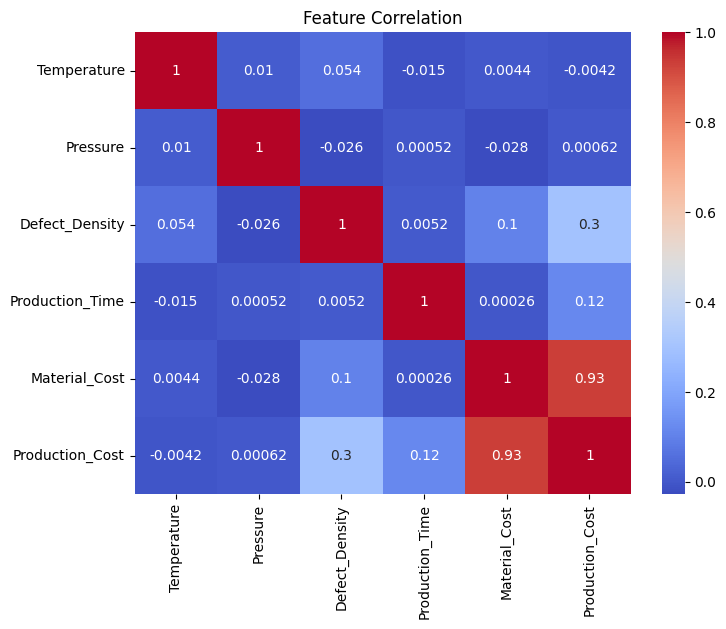

In [3]:
#3. EDA (EXPLORATORY DATA ANALYSIS)
print("\nDataset Info:")
print(data.info())

print("\nCorrelation Matrix:")
print(data.corr())

# Plot correlation heatmap
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [4]:
# 4. DATA PREPROCESSING
X = data.drop('Production_Cost', axis=1)
y = data['Production_Cost']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 5. MODEL BUILDING (NEURAL NETWORK)
model = MLPRegressor(max_iter=500, random_state=42)

# Hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(50,50), (100,)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

grid_search = GridSearchCV(model, param_grid, cv=3, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}


In [6]:
# 6. MODEL EVALUATION
y_pred = best_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nRMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")


RMSE: 19.61
R2 Score: 0.92


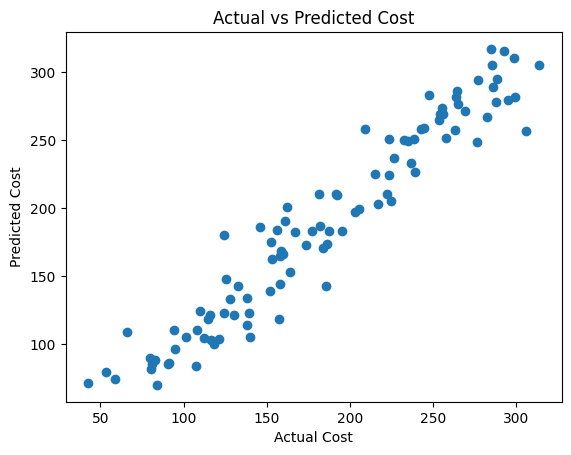

In [7]:
# 7. VISUALIZATION
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cost")
plt.show()

In [8]:
# 8. SAVE MODEL & SCALER
pickle.dump(best_model, open("neural_network_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nModel and scaler saved successfully!")


Model and scaler saved successfully!
